# Chatty Maps - Zurich

This project recreates the Chatty Maps study by Aiello et al. (2016) for the
city of Zurich. The aim is to colour each street by the kind of sound most
often associated with it, using the words people attach to geolocated Flickr
photos as a proxy for the urban soundscape.

The work was done for GEO877 Spatial Algorithms, so the spatial operations are
written from scratch rather than taken from a library. Three algorithms form
the core of the analysis.

1. **Street segmentation** cuts the long street polylines into shorter pieces
   so that each one can carry its own sound profile.
2. **Buffer construction** builds a polygon of a fixed width around every
   segment, defining the area in which a photo counts towards that street. It
   follows the circle-and-sweep idea from the lecture, inspired by Minkowski
   sums.
3. **Ray casting** decides which buffers each photo falls inside, using the
   even-odd rule from the lecture with the special cases for collinear edges
   and shared vertices handled.

Before the spatial work, the photo tags are sorted into a sound taxonomy of six
main categories (transport, mechanical, human, music, nature, indoor), each
split into more specific subcategories. A sound wheel then visualises how often
each category appears, in the same spirit as the original paper.

The analysis draws on two datasets. The Flickr CH collection provides the
photos and their tags for the whole of Switzerland, which we filter down to the
Zurich area. The street network comes from the official Zurich street register,
in the Swiss coordinate system EPSG:2056 (CH1903+ LV95, metres), with the
street name stored in the STN_TEXT field. Since the photos arrive in WGS84
degrees, they are reprojected into EPSG:2056 before any matching so that points
and buffers share one coordinate system.

The final map shows the Zurich street network with every matched segment
coloured by its dominant sound category.

In [1]:
# data import 
import pandas as pd
import plotly.express as px

flickr_zurich = pd.read_csv(
    "data/Flickr_ZURICH.csv", 
    low_memory=False)

zurich_posts = len(flickr_zurich)
print(f"Posts in Zürich-Bounding-Box: {zurich_posts}")



# preparation of the tags
flickr_zurich["tags"] = flickr_zurich["tags"].fillna("")  # replaces missing tags with an empty string

# cleaning the tags
flickr_zurich["tags_list"] = (
    flickr_zurich["tags"]
    .astype(str)                              # turn tags into text
    .str.lower()                              # make everything lowercase
    .str.replace("#", "", regex=False)        # remove hashtags
    .str.split(",")                           # split the tag strings into a list
)

Posts in Zürich-Bounding-Box: 235006


Based on the data from Aiello et al. (2016) and our own evaluation after looking at the dataset, we built the sound dictionary. It is structured in three categories: main category, sub category and words. 

In [ ]:

# Sound dictionary 

sound_taxonomy = {
    "transport": {
        "road": [
            "car", "cars", "traffic", "road", "street", "motor", "engine", "auto", "autos", "verkehr", "strasse", "straße", "route"
        ],
        "rail": [
            "train", "railway", "rail", "tracks", "tram", "sbb", "zug", "bahn", "gleis", "tramway"
        ],
        "air": [
            "airplane", "plane", "helicopter", "airport", "flugzeug", "helikopter", "flughafen"
        ]
    },

    "mechanical": {
        "construction": [
            "construction", "building", "drilling", "tools", "baustelle", "bau", "bohren", "hammer"
        ],
        "machines": [
            "machine", "machinery", "mechanical", "industrial", "maschine", "maschinen", "industrie"
        ],
        "signals": [
            "alarm", "siren", "horn", "ringing", "sirene", "hupe", 
        ]
    },

    "human": {
        "voice": [
            "voice", "talk", "talking", "speaking", "conversation", "stimme", "sprechen", "gespräch", "reden"
        ],
        "crowd": [
            "people", "crowd", "public", "market", "menschen", "menge", "publikum", "markt"
        ],
        "children": [
            "kids", "children", "baby", "playground", "kinder", "kind", "baby", "spielplatz"
        ],
        "movement": [
            "walking", "running", "footsteps", "hiking", "hike", "laufen", "gehen", "schritte", "jogging", "wandern", "wanderung"
        ]
    },

    "music": {
        "music_general": [
            "music", "song", "sound", "concert", "festival", "musik", "lied", "konzert", "rave"
        ],
        "instruments": [
            "guitar", "piano", "trumpet", "drum", "gitarre", "klavier", "trompete", "schlagzeug"
        ],
        "media": [
            "radio", "dj", "recording", "club", "aufnahme", "platte", "disco", "disko"
        ]
    },

    "nature": {
        "water": [
            "water", "river", "lake", "rain", "waves", "stream", "wasser", "fluss", "see", "regen", "wellen", "bach"
        ],
        "weather": [
            "storm", "thunder", "snow", "wind", "sturm", "donner", "schnee"
        ],
        "animals": [
            "bird", "birds", "dog", "cat", "animal", "vogel", "vögel", "hund", "katze", "tier", "duck", "ducks", "ente", "enten"
        ],
        "vegetation": [
            "forest", "tree", "trees", "leaves", "park", "wald", "baum", "bäume", "blätter", "blatt"
        ]
    },

    "indoor": {
        "home": [
            "home", "house", "room", "kitchen", "shower", "haus", "wohnung", "zimmer", "küche", "dusche", "balcony", "balkon", 
            "rooftop", "dachterrasse", "terrasse"
        ],
        "office": [
            "office", "computer", "paper", "keyboard", "büro", "papier", "tastatur"
        ],
        "hospitality": ["restaurant", "bar", "cafe", "café", "kaffee", "hotel"
        ],
        "church": ["church", "bell", "organ", "kirche", "glocke", "orgel"
        ]
    }
}


# matching the sound tags to the sound categories from the dictionary
def match_sound_tags(tags, taxonomy):  # receives the tag list of one photo + the taxonomy
    matches = []                       # starts with an empty list
    for tag in tags:
        tag = tag.strip()              # remove extra spaces
        for main_cat, subcats in taxonomy.items():
            for sub_cat, words in subcats.items():
                if tag in words:       # is the tag in one of the sound-word lists?
                    matches.append({
                        "tag": tag,
                        "main_category": main_cat,
                        "sub_category": sub_cat,
                    })
    return matches                     # all sound matches for one photo


flickr_zurich["sound_matches"] = flickr_zurich["tags_list"].apply(
    lambda x: match_sound_tags(x, sound_taxonomy)
)

# build the long-format sound dataframe 
sound_match_rows = []
for _, row in flickr_zurich.iterrows():
    for match in row["sound_matches"]:
        sound_match_rows.append(match)

sound_matches = pd.DataFrame(sound_match_rows)
print("Total sound tags:", len(sound_matches))
print(sound_matches.head())

# top words per category
top_words = (
    sound_matches
    .groupby(["main_category", "sub_category", "tag"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(top_words.head(20))


# Visualization 
# sound wheel (sunburst), like in Aiello et al. 2016
import plotly.express as px

CAT_COLORS = {
    "transport":  "#e6194B",
    "mechanical": "#808080",
    "human":      "#f58231",
    "music":      "#911eb4",
    "nature":     "#3cb44b",
    "indoor":     "#4363d8",
}

top_plot = (
    top_words
    .groupby(["main_category", "sub_category"])
    .head(5)
    .copy()
)

# every tag gets the same weight
top_plot["equal_weight"] = 1

fig = px.sunburst(
    top_plot,
    path=["main_category", "sub_category", "tag"],
    values="equal_weight",
    color="main_category",
    color_discrete_map=CAT_COLORS,
    title="Soundwheel Zürich",
    width=1200,
    height=1200
)

fig.update_layout(
    font=dict(size=14),
    margin=dict(t=80, l=20, r=20, b=20)
)

fig.show()

Total sound tags: 81143
      tag main_category sub_category
0   train     transport         rail
1  tracks     transport         rail
2     sbb     transport         rail
3     sbb     transport         rail
4     sbb     transport         rail
    main_category   sub_category        tag  count
164     transport           road     street   6681
139     transport            air    airport   4075
122        nature          water       lake   3122
93          music  music_general      music   2961
149     transport           rail        sbb   2808
90          music  music_general    concert   2438
163     transport           road    strasse   2259
140     transport            air  flughafen   2180
151     transport           rail      train   2138
12          human          crowd     people   1917
133        nature        weather       snow   1853
126        nature          water        see   1838
129        nature          water      water   1730
152     transport           rail       t

## Algorithm 1 - Street segmentation
Within this algorithm the classes `Point` and `Polyline` were defined. The classes contain multiple functions which are used for all spatial algorithms. For a quick overview, all functions are briefly listed below.

**Point** <br>
- `__init__(x, y)`: Definition of a point with x and y coordinates
- `distanceTo(other)`: Calculates the Euclidean distance between two points
- `toTuple()`: Turns point into a tuple (`(x, y)`)
- `isEqual(other)`: Checks if two points have identical coordinates
- `__repr__()`: Returns a readable string representation (`Point(x, y)`)
- `__eq__(other)`: Enables comparison of two points
- `__hash__()`: Makes points hashable so they can be used in sets or dictionaries

**Polyline** <br>
- `__init__(coords)`: Creates a polyline from coordinate pairs and removes consecutive duplicate points <br>
- `totalLength()`: Computes the total length of the polyline <br>
- `interpolatePoint(dist)`:Returns the point located at a specified distance along the polyline <br>
- `cutSegment(start, end)`: Extracts a sub-polyline between two distances along the line <br>
- `toCoords()`: Returns all polyline points as a list of coordinate tuples <br>
- `splitInto(max_len)`: Splits the polyline into smaller segments with a maximum specified length

    Shape_Leng  STR_ESID  OBJECTID_1  STN_ID  STR_ESID_1            STN_TEXT  \
0   603.697939  10059061         103  494281    10059061           Dangelweg   
1   797.554273  10080505         108  511204    10080505  Waffenplatzstrasse   
2  1696.222673  10249346         111  744994    10249346       Buchenrainweg   
3  1534.809565  10006654         113  454361    10006654         Rämistrasse   
4   254.392500  10249411         114  745059    10249411      Hürlimannplatz   

  STN_INDEX  STN_LANGUA  OBJECTID_2  STR_ESID_2  ...  COM_NAME COM_CANTON  \
0       Dan           0         103           0  ...    Zürich         ZH   
1       Waf           0         108           0  ...    Zürich         ZH   
2       Buc           0         111           0  ...    Zürich         ZH   
3        Rä           0         113           0  ...    Zürich         ZH   
4        Hü           0         114           0  ...    Zürich         ZH   

  STR_TYPE  STR_STATUS  STR_OFFICI  STR_GEOMSR  STR_PARE

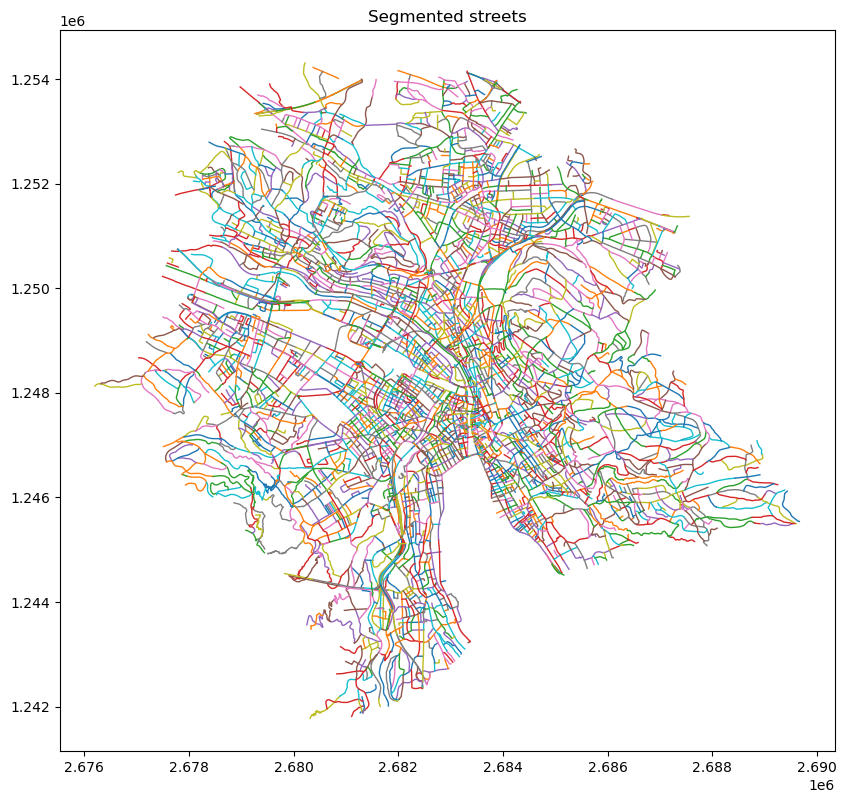

In [ ]:
# Split each street polyline into segments of at most MAX_LEN metres.

import geopandas as gpd          # reading and handling geospatial data
import matplotlib.pyplot as plt  # plotting
import pandas as pd              # tabular data handling


# Geometry helper classes (used by all three algorithms)
# Point
class Point():
    def __init__(self, x, y):
        self.x = x
        self.y = y

    #calculates Euclidean distance between two points
    def distanceTo(self, other):
        return ((self.x - other.x)**2 + (self.y - other.y)**2) ** 0.5

    #returns (x, y) tuple which is further used for storing
    def toTuple(self):
        return (self.x, self.y)

    #checks if two points are identical
    def isEqual(self, other):
        return self.x == other.x and self.y == other.y

    #enables following representation: Point(x,y) for better reading purposes
    def __repr__(self):
        return f'Point({self.x}, {self.y})'


    def __eq__(self, other):
        return isinstance(other, Point) and self.x == other.x and self.y == other.y

    def __hash__(self):
        return hash((self.x, self.y))

# Polyline
class Polyline():
    # line made of multiple connected points
    def __init__(self, coords):

        # Read coordinates while filtering out consecutive duplicate points.
        all_points = [Point(x, y) for x, y in coords]
        self.points = [all_points[0]]
        for p in all_points[1:]:
            if p.x != self.points[-1].x or p.y != self.points[-1].y:
                self.points.append(p)

    # computes total length of the polyline
    def totalLength(self):
        return sum(
            self.points[i].distanceTo(self.points[i+1])
            for i in range(len(self.points) - 1))

    #defines point at a given distance (for splitting segments)
    def interpolatePoint(self, dist):
        walked = 0.0

        for i in range(len(self.points) - 1):
            a = self.points[i]
            b = self.points[i + 1]
            edge = a.distanceTo(b)

            # Check if target distance lies on this segment
            if walked + edge >= dist:
                t = (dist - walked) / edge  # interpolation factor (0→1)
                return Point(
                    a.x + t * (b.x - a.x),
                    a.y + t * (b.y - a.y)
                )

            walked += edge

        # If distance exceeds total length, return last point
        return self.points[-1]

    # extract a sub-polyline between distances 'start' and 'end'
    def cutSegment(self, start, end):
        pts = [self.interpolatePoint(start)]
        walked = 0.0

        for i in range(len(self.points) - 1):
            a = self.points[i]
            b = self.points[i + 1]
            edge = a.distanceTo(b)
            mid = walked + edge

            # Include intermediate points if they lie inside the segment
            if mid > start and walked < end:
                if mid < end:
                    pts.append(b)

            walked += edge

            # Stop once we've reached the end distance
            if walked >= end:
                break

        pts.append(self.interpolatePoint(end))

        return Polyline([p.toTuple() for p in pts])

    # Returns list of coordinate tuples
    def toCoords(self):
        return [p.toTuple() for p in self.points]

    # Splits polyline into smaller segments of max length 'max_len'
    def splitInto(self, max_len):
        total = self.totalLength()
        start = 0.0
        seg_id = 0

        while start < total:
            end = min(start + max_len, total)

            yield seg_id, self.cutSegment(start, end)

            start += max_len
            seg_id += 1

# Load shapefile & segment lines
NAME_COLUMN = "STN_TEXT"   # attribute column with the street name (needs the .dbf)
MAX_LEN = 1000             # maximum segment length in metres

gdf = gpd.read_file("data/Streets_filtered_Zurich.shp", engine="fiona")
# CRS comes from the .prj (EPSG:2056, CH1903+/LV95, metres) and the street
# name from the .dbf (STN_TEXT column).

print(gdf.head())

rows = []   # all generated segments
uid = 0

for idx, row in gdf.iterrows():
    geom = row.geometry
    if geom is None:
        continue

    # handle both LineString and MultiLineString geometries
    parts = list(geom.geoms) if geom.geom_type == "MultiLineString" else [geom]

    for part in parts:
        polyline = Polyline(list(part.coords))
        for seg_id, seg in polyline.splitInto(MAX_LEN):
            rows.append({
                "name": row[NAME_COLUMN],
                "unique_id": uid,
                "seg_id": seg_id,
                "seg_len_m": round(seg.totalLength(), 2),
                "coords": seg.toCoords(),
            })
            uid += 1

print(f"Created {len(rows)} segments")

df_street_segments = pd.DataFrame(rows)   # df now holds the street segments
print(df_street_segments.head(10))

# Plot segmented streets
fig, ax = plt.subplots(figsize=(10, 10))
for r in rows:
    xs = [p[0] for p in r["coords"]]
    ys = [p[1] for p in r["coords"]]
    ax.plot(xs, ys, linewidth=1)
ax.set_title("Segmented streets")
ax.set_aspect("equal")
plt.show()

## Algorithm 2 - Buffer construction

Below the buffer around each street segment is calculated. For this the function `line_intersection(p1, d1, p2, d2)` and `buffer(pts, width, num_circle_points=12)` are generated. Within the buffer-function a turn test function is integrated to test the direction of each edge within the segment. The `line_intersection(p1, d1, p2, d2)` calculates the intersection point of two infinite lines, which is used to determine the inner edge point of the buffered polygon. 



In [ ]:

import math

# Calculate intersection point if two lines intersect
def line_intersection(p1, d1, p2, d2):
    dx1, dy1 = d1
    dx2, dy2 = d2
    denom = dx1 * dy2 - dy1 * dx2
    if abs(denom) < 1e-10:
        return None
    t = ((p2.x - p1.x) * dy2 - (p2.y - p1.y) * dx2) / denom
    return Point(p1.x + t * dx1, p1.y + t * dy1)

def buffer(pts, width, num_circle_points=12):
    #calculate segment length
    n = len(pts)
    
    # calculate buffer radius
    r = width / 2

    # create lists for the created polygon points
    left_side  = []
    right_side = []

    # calculate unit and normal vector
    def unit_vector(ax, ay, bx, by):
        dx, dy = bx - ax, by - ay
        length = math.sqrt(dx*dx + dy*dy)
        return (dx/length, dy/length) if length else (0.0, 0.0)

    dx,  dy = unit_vector(pts[0].x, pts[0].y, pts[1].x, pts[1].y)
    nx,  ny = -dy, dx

    # Create the start caps of the polygon, based on points parallel to the starting points
    left_side.append( (pts[0].x + nx*r, pts[0].y + ny*r))
    right_side.append((pts[0].x - nx*r, pts[0].y - ny*r))

    for i in range(n - 1):
        p0, p1 = pts[i], pts[i + 1]
        
        # the point is not a starting or ending point
        if i < n - 2:
            p2 = pts[i + 2]

            dx2, dy2 = unit_vector(p1.x, p1.y, p2.x, p2.y)
            nx2, ny2 = -dy2, dx2

            # do turn test
            t = (p1.x - p0.x) * (p2.y - p0.y) - (p1.y - p0.y) * (p2.x - p0.x)

            # calculate angles
            angle_in  = math.atan2(ny,  nx)
            angle_out = math.atan2(ny2, nx2)

            # create left arc on right turn 
            if t < 0: 
                diff     = (angle_out - angle_in + math.pi) % (2*math.pi) - math.pi
                left_side.extend(
                    (p1.x + r * math.cos(angle_in + diff * j / num_circle_points),
                     p1.y + r * math.sin(angle_in + diff * j / num_circle_points))
                    for j in range(num_circle_points + 1))
                
                right_side.append((p1.x - nx*r,  p1.y - ny*r))
                inner = line_intersection(
                    Point(p0.x - nx*r,  p0.y - ny*r),  (dx,  dy),
                    Point(p2.x - nx2*r, p2.y - ny2*r), (dx2, dy2))
                right_side.append((inner.x, inner.y) if inner else (p1.x - nx*r, p1.y - ny*r))

            # create right arc on left turn
            elif t > 0: 
                angle_in_r  = math.atan2(-ny,  -nx)
                angle_out_r = math.atan2(-ny2, -nx2)
                diff_r      = (angle_out_r - angle_in_r + math.pi) % (2*math.pi) - math.pi
                right_side.extend(
                    (p1.x + r * math.cos(angle_in_r + diff_r * j / num_circle_points),
                     p1.y + r * math.sin(angle_in_r + diff_r * j / num_circle_points))
                    for j in range(num_circle_points + 1))
                
                left_side.append((p1.x + nx*r,  p1.y + ny*r))
                inner = line_intersection(
                    Point(p0.x + nx*r,  p0.y + ny*r),  (dx,  dy),
                    Point(p2.x + nx2*r, p2.y + ny2*r), (dx2, dy2))
                left_side.append((inner.x, inner.y) if inner else (p1.x + nx*r, p1.y + ny*r))

            # no turn (t==0)
            else: 
                left_side.append( (p1.x + nx*r,  p1.y + ny*r))
                right_side.append((p1.x - nx*r,  p1.y - ny*r))

            dx,  dy = dx2,  dy2
            nx,  ny = nx2,  ny2
        
        # last point on segment, creates end cap points
        else: 
            left_side.append( (p1.x + nx*r,  p1.y + ny*r))
            right_side.append((p1.x - nx*r,  p1.y - ny*r))

    outline = left_side + list(reversed(right_side))
    outline.append(outline[0])
    return outline

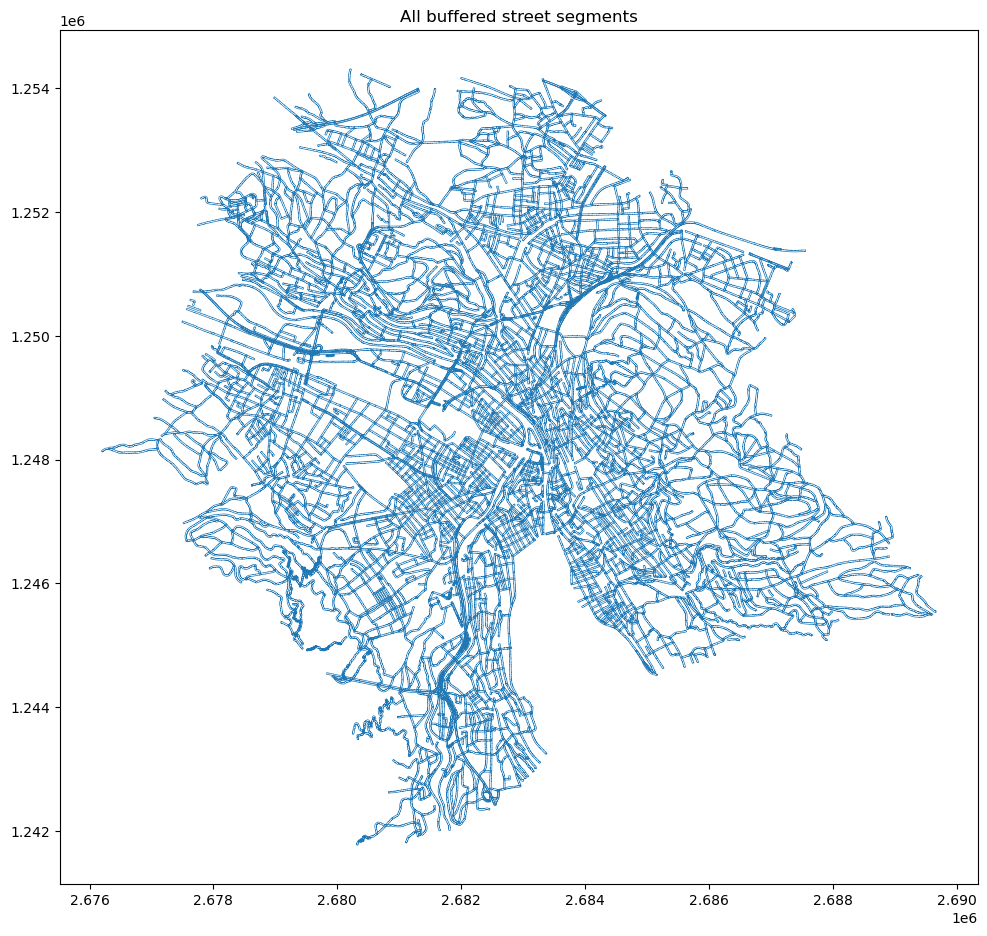

In [5]:
from matplotlib.collections import LineCollection

# Only buffer street segments which are at longer than 100 m to avoid overlaps
df_filtered = df_street_segments[df_street_segments["seg_len_m"] >= 100].copy()

# Applying the buffer on the filtered street segments
df_filtered["buffer"] = df_filtered["coords"].apply(
    lambda coords: buffer([Point(x, y) for x, y in coords], width=25))

# Plot all buffered segments
fig, ax = plt.subplots(figsize=(10, 10))

lines = [coords for coords in df_filtered["buffer"] if coords]
ax.add_collection(LineCollection(lines, linewidths=0.5))
ax.autoscale()
ax.set_aspect("equal")
ax.set_title("All buffered street segments")
plt.tight_layout()
plt.show()

## Algorithm 3 - Ray casting (matching photos to streets)

Point-in-polygon test using the ray casting / even-odd rule from the lecture: bounding-box check, a horizontal ray, counting edge crossings, and the even-odd decision, with the special cases handled (horizontal/collinear edges are skipped and a shared vertex is counted once).
The goal is to assign each Flickr photo to the street buffer it belongs to and then take the most frequent main sound category as the segment's dominant sound. 

In [ ]:


import numpy as np
from collections import Counter

# The streets are in EPSG:2056 (metres) but the Flickr coordinates are WGS84 lat/lng (degrees)
# We reproject the photos into the street CRS so that points and buffers live in the same coordinate system.

zurich_sound = flickr_zurich[flickr_zurich["sound_matches"].map(len) > 0].copy()

pts = gpd.GeoSeries(
    gpd.points_from_xy(zurich_sound["lng"], zurich_sound["lat"]),
    crs=4326,
).to_crs(2056)

px_arr = pts.x.to_numpy()
py_arr = pts.y.to_numpy()

# main sound category list per photo (a photo can carry several categories)
photo_cats = [
    [m["main_category"] for m in matches]
    for matches in zurich_sound["sound_matches"]
]
print(f"Flickr photos with at least one sound tag: {len(px_arr)}")


def point_in_polygon(px, py, polygon):
    """
    Ray casting (even-odd rule)
    Step 1  Bounding-box check: if the point lies outside the polygon's
            bounding box it cannot be inside, so we stop early.
    Step 2  Cast a horizontal ray from the point towards +x (to the right).
    Step 3  Count how many polygon edges that ray crosses.
    Step 4  Even number of crossings -> outside, odd -> inside.

    polygon is a list of (x, y) vertices. Returns True if (px, py) is inside.
    """
    # drop the repeated closing vertex if present, then treat the ring as closed
    pts = polygon[:-1] if len(polygon) > 1 and polygon[0] == polygon[-1] else polygon
    n = len(pts)
    if n < 3:
        return False

    # Step 1: polygon bounding box
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    if not (min(xs) <= px <= max(xs) and min(ys) <= py <= max(ys)):
        return False

    # Steps 2 & 3: horizontal ray to the right, count edge crossings
    count = 0
    for i in range(n):
        ax, ay = pts[i]
        bx, by = pts[(i + 1) % n]

        # Special case (collinear / horizontal edge): the edge runs along the
        # ray's direction, so we do not count it.
        if ay == by:
            continue

        # Half-open rule for the y-band: the edge crosses the ray's height only when exactly one endpoint is strictly above py
        # including the lower endpoint but excluding the upper one makes a shared vertex count once
        if (ay > py) != (by > py):
            # x-coordinate where this edge meets the ray's height
            x_cross = ax + (py - ay) * (bx - ax) / (by - ay)
            if x_cross > px:          # the crossing is to the right of the point
                count += 1

    # Step 4: even-odd rule
    return count % 2 == 1


dominant = []     # most frequent main category per segment
n_sound = []      # number of category hits per segment

for _, row in df_filtered.iterrows():
    poly = row["buffer"]

    # Bounding-box screening for the whole point set 
    # only pictures inside the buffer's bounding box go on to the full ray casting test
    bx = [p[0] for p in poly]
    by = [p[1] for p in poly]
    in_box = (px_arr >= min(bx)) & (px_arr <= max(bx)) & \
             (py_arr >= min(by)) & (py_arr <= max(by))
    candidates = np.nonzero(in_box)[0]

    counts = Counter()
    for k in candidates:
        if point_in_polygon(px_arr[k], py_arr[k], poly):
            counts.update(photo_cats[k])

    n_sound.append(sum(counts.values()))
    dominant.append(counts.most_common(1)[0][0] if counts else None)

df_filtered["dominant"] = dominant
df_filtered["n_sound"] = n_sound

matched = df_filtered["dominant"].notna().sum()
print(f"Segments with at least one matched sound: {matched} / {len(df_filtered)}")
print(df_filtered["dominant"].value_counts(dropna=False))

Flickr photos with at least one sound tag: 46128
Segments with at least one matched sound: 954 / 2851
dominant
None          1897
transport      387
nature         307
indoor         127
music           57
human           42
mechanical      34
Name: count, dtype: int64


## Final map

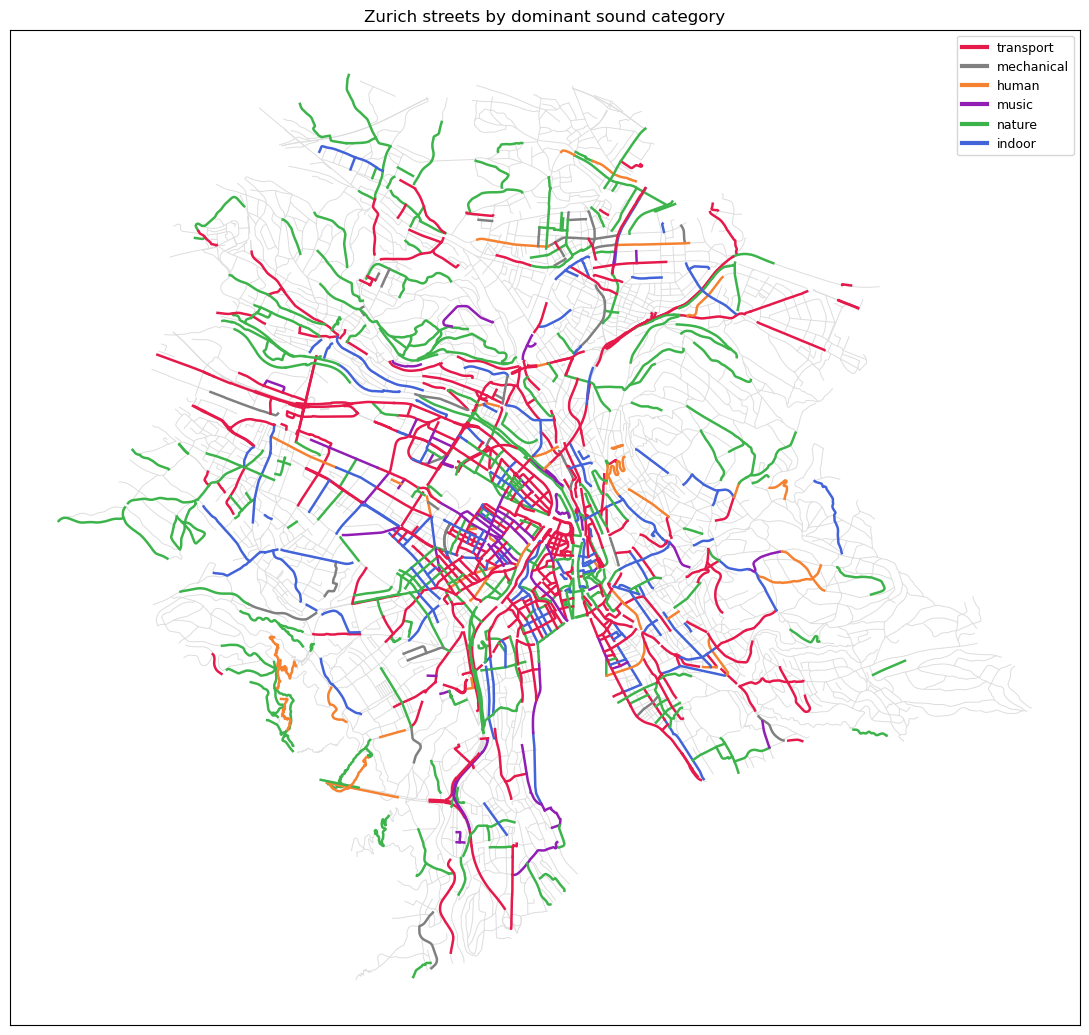

In [ ]:
# Streets coloured by dominant sound category


from matplotlib.lines import Line2D

# use the colours from the Sound Wheel 
CAT_COLORS = {
    "transport":  "#e6194B",
    "mechanical": "#808080",
    "human":      "#f58231",
    "music":      "#911eb4",
    "nature":     "#3cb44b",
    "indoor":     "#4363d8",
}

fig, ax = plt.subplots(figsize=(11, 11))

# draw segments without any matched sound first, as a light grey background
for _, r in df_filtered[df_filtered["dominant"].isna()].iterrows():
    xs = [p[0] for p in r["coords"]]
    ys = [p[1] for p in r["coords"]]
    ax.plot(xs, ys, color="#dddddd", linewidth=0.7, zorder=1)

# draw coloured segments on top
for _, r in df_filtered[df_filtered["dominant"].notna()].iterrows():
    xs = [p[0] for p in r["coords"]]
    ys = [p[1] for p in r["coords"]]
    ax.plot(xs, ys, color=CAT_COLORS[r["dominant"]], linewidth=1.8, zorder=2)

ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Zurich streets by dominant sound category")

legend = [Line2D([0], [0], color=c, lw=3, label=k) for k, c in CAT_COLORS.items()]
ax.legend(handles=legend, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("zurich_soundmap.png", dpi=150)
plt.show()